In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
AVAdata = pd.read_csv("ValidZipCodeData.csv")
AVAdata.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
0,50299400,2025,3031482,1364125,4395607,22314
1,50299400,2024,3031482,1364125,4395607,22314
2,50299400,2023,3031482,1364125,4395607,22314
3,50299400,2022,3031482,1364125,4395607,22314
4,50299400,2021,3031482,1364125,4395607,22314


In [3]:
ZipCodeColors = ["brown", "purple", "blue", "green", "yellow", "orange", "red", "pink"]

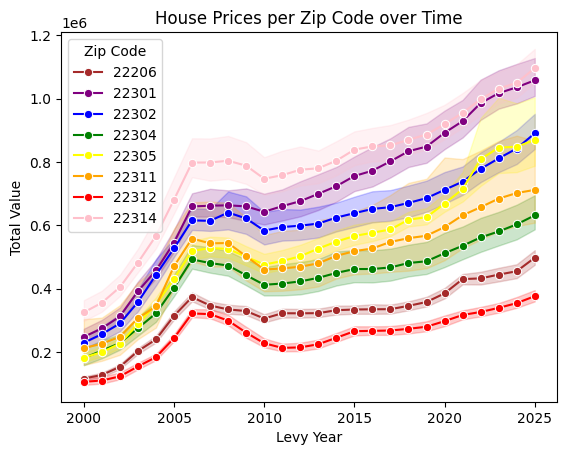

In [4]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

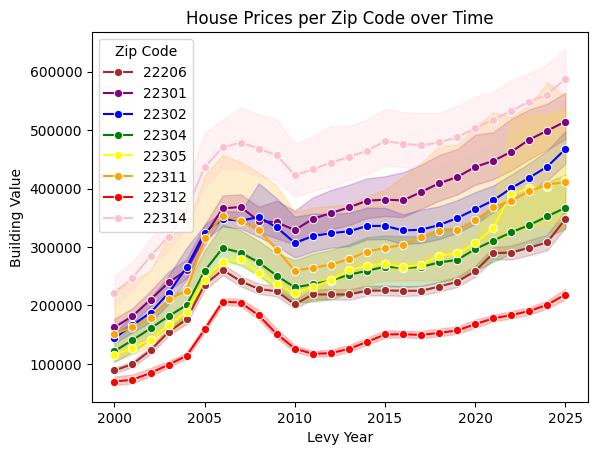

In [5]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Building Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

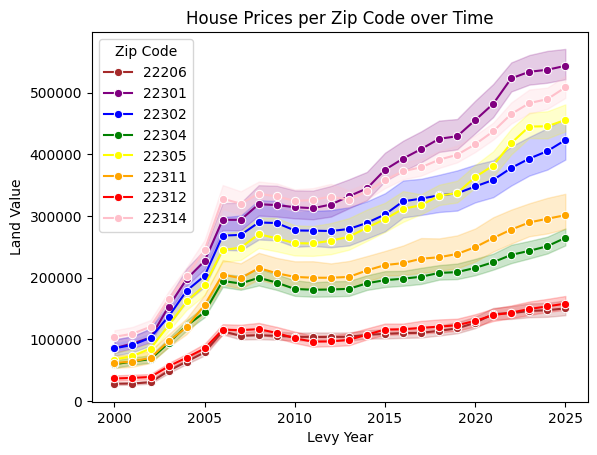

In [6]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Land Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

We need to put some of the zip codes into other zip codes, because there are only 8 that make up the map display of Alexandria Zip Codes. Some are just smaller zip code markers essentially. 

In [8]:
AVAdata.dtypes

Account Number    int64
Levy Year         int64
Land Value        int64
Building Value    int64
Total Value       int64
Zip Code          int64
dtype: object

In [9]:
AccountData = AVAdata.groupby("Account Number").agg({"Land Value": "mean", "Building Value": "mean", "Total Value": "mean", "Zip Code": "first", "Levy Year":list}).reset_index()
AccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
...,...,...,...,...,...,...
32672,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025]
32673,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025]
32674,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025]
32675,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025]


In [10]:
AvaBuildLand = pd.read_csv("Ava_Streets_Table.csv").rename(columns={"A_Account_Num": "Account Number"})
AvaBuildLand.head()

,Unnamed: 0,A_Properties,A_Current_Owner,Account Number,A_SQFT
0,1,3000 S 28TH ST,\r\r\n\t\t\t\t\t\tCITY OF ALEXANDRIA\t\t,50299410,1
1,2,3102 S 28TH ST,\r\r\n\t\t\t\t\t\tALEXANDRIA REDEVELOPMENTHOUS...,50299400,1
2,3,"3200 S 28TH ST, UNIT 101",\r\r\n\t\t\t\t\t\tBEGUM SAIRAKHALEK MOHAMMAD A...,50466800,1090
3,4,"3200 S 28TH ST, UNIT 102",\r\r\n\t\t\t\t\t\tCHESLEY JOHN W III AND JUDIT...,50466810,1280
4,5,"3200 S 28TH ST, UNIT 201",\r\r\n\t\t\t\t\t\tSILVA HUGO TRNEGRONI ANDREA ...,50466820,700


In [11]:
AvaBuildLand = AvaBuildLand.drop(columns={"Unnamed: 0"})
AvaBuildLand.head()

,A_Properties,A_Current_Owner,Account Number,A_SQFT
0,3000 S 28TH ST,\r\r\n\t\t\t\t\t\tCITY OF ALEXANDRIA\t\t,50299410,1
1,3102 S 28TH ST,\r\r\n\t\t\t\t\t\tALEXANDRIA REDEVELOPMENTHOUS...,50299400,1
2,"3200 S 28TH ST, UNIT 101",\r\r\n\t\t\t\t\t\tBEGUM SAIRAKHALEK MOHAMMAD A...,50466800,1090
3,"3200 S 28TH ST, UNIT 102",\r\r\n\t\t\t\t\t\tCHESLEY JOHN W III AND JUDIT...,50466810,1280
4,"3200 S 28TH ST, UNIT 201",\r\r\n\t\t\t\t\t\tSILVA HUGO TRNEGRONI ANDREA ...,50466820,700


In [12]:
FullAccountData = pd.merge(AccountData, AvaBuildLand, how="left", on="Account Number")
FullAccountData.head()

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",309 HOLLAND LA,\r\r\n\t\t\t\t\t\tROYALTON CONDOMINIUM\t\t,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",500 HOLLAND LA,\r\r\n\t\t\t\t\t\tBAPTIST CEMETARY ASSOC OF AL...,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",205 DAINGERFIELD RD,\r\r\n\t\t\t\t\t\tNATIONAL SOCIETY OF BLACK EN...,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1601A DUKE ST,\r\r\n\t\t\t\t\t\tVINCI EDUCATION CORPORATION\t\t,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1603 DUKE ST,\r\r\n\t\t\t\t\t\tVINCI EDUCATION CORPORATION\t\t,0


In [13]:
FullAccountData["A_Current_Owner"] = FullAccountData["A_Current_Owner"].str.replace(r"[\r\n\t]+", "", regex=True)
FullAccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",309 HOLLAND LA,ROYALTON CONDOMINIUM,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",500 HOLLAND LA,BAPTIST CEMETARY ASSOC OF ALEXANDRIA,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",205 DAINGERFIELD RD,NATIONAL SOCIETY OF BLACK ENGINEERS,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1601A DUKE ST,VINCI EDUCATION CORPORATION,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1603 DUKE ST,VINCI EDUCATION CORPORATION,0
...,...,...,...,...,...,...,...,...,...
32714,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],4922 CUMBERLAND ST,ELAMIN SARAH OR WAILE,1950
32715,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],4920 CUMBERLAND ST,XIAO GUOXIAN OR CHANG QING,1950
32716,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],4918 CUMBERLAND ST,PETERSON ERIK OR GEORGE NIDHI,1950
32717,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],4916 CUMBERLAND ST,THORNTON JAYSON MICHAELOR THORNTON MARQUITA MI...,1950


In [14]:
FullAccountData["A_Properties"] = FullAccountData["A_Properties"].str.replace(r"([0-9]+).", "", regex=True)
FullAccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",HOLLAND LA,ROYALTON CONDOMINIUM,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",HOLLAND LA,BAPTIST CEMETARY ASSOC OF ALEXANDRIA,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DAINGERFIELD RD,NATIONAL SOCIETY OF BLACK ENGINEERS,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DUKE ST,VINCI EDUCATION CORPORATION,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DUKE ST,VINCI EDUCATION CORPORATION,0
...,...,...,...,...,...,...,...,...,...
32714,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],CUMBERLAND ST,ELAMIN SARAH OR WAILE,1950
32715,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],CUMBERLAND ST,XIAO GUOXIAN OR CHANG QING,1950
32716,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],CUMBERLAND ST,PETERSON ERIK OR GEORGE NIDHI,1950
32717,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],CUMBERLAND ST,THORNTON JAYSON MICHAELOR THORNTON MARQUITA MI...,1950


The Long Short-Term Memory network, or LSTM network, is a recurrent neural network trained using Backpropagation Through Time that overcomes the vanishing gradient problem.

In [16]:
OwnerDataTable = FullAccountData.groupby('A_Current_Owner').agg({'Land Value':'sum', 'Building Value':'sum', 'Total Value':'sum','A_SQFT':'sum'})
OwnerDataTable.head()

,Land Value,Building Value,Total Value,A_SQFT
A_Current_Owner,,,,
,9.000856e+06,1.071781e+07,1.971866e+07,54267
ALLEN RUSSELL OR FRIEDMAN KYLE REBECCA,2.120592e+05,1.563995e+05,3.684588e+05,860
CORONA ANNA MARIEROMERO ANDREW,2.238037e+05,2.487135e+05,4.725171e+05,1102
IGYARTO KEITH EDWARD AND LORI PEARL TRS,5.756726e+05,6.359418e+05,1.211614e+06,3060
JASTRAB DAVID OR STERLING AMANDA,3.379823e+05,3.317128e+05,6.696951e+05,1904


## Time Series Analysis

In [18]:
AVAdata.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
0,50299400,2025,3031482,1364125,4395607,22314
1,50299400,2024,3031482,1364125,4395607,22314
2,50299400,2023,3031482,1364125,4395607,22314
3,50299400,2022,3031482,1364125,4395607,22314
4,50299400,2021,3031482,1364125,4395607,22314


### Cross Validation

In [20]:
from sklearn.model_selection import TimeSeriesSplit

AVAdata = AVAdata.sort_values(by = "Levy Year", ascending = True)
AVAdata.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
406165,50637920,2000,31600,117000,148600,22311
289492,13218500,2000,45300,93900,139200,22301
289518,13218000,2000,41100,93400,134500,22314
289544,13217000,2000,41100,85000,126100,22301
289570,13216500,2000,41100,85000,126100,22314


<Axes: xlabel='Levy Year', ylabel='Total Value'>

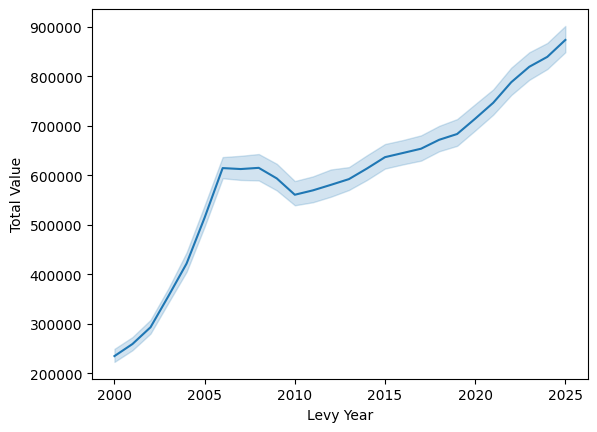

In [21]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value")

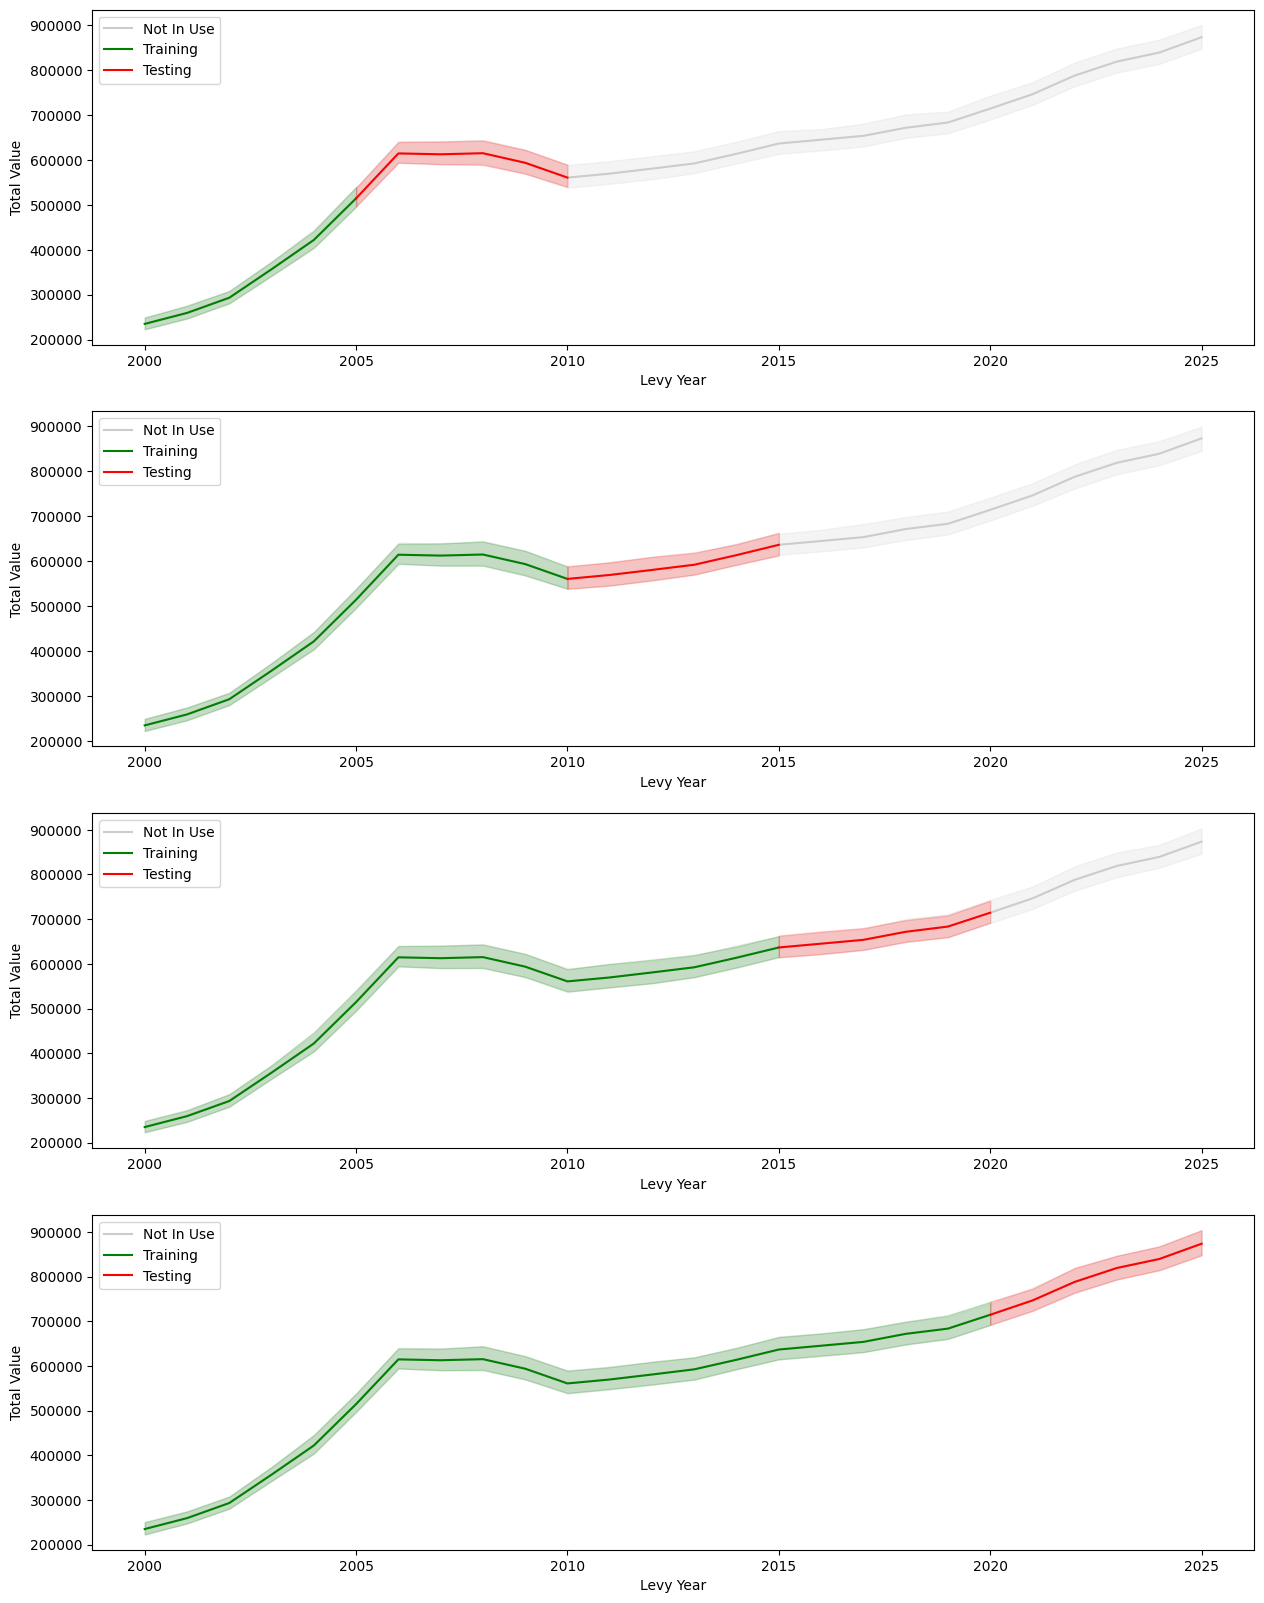

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(15, 20))
for i, year in enumerate(range(2005, 2021, 5)):
    trainingdata = AVAdata[AVAdata["Levy Year"] <= year]
    testingdata = AVAdata[(AVAdata["Levy Year"] >= year) & (AVAdata["Levy Year"] <= (year+5))]
    sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value", label = "Not In Use", color="0.8", ax=axes[i])
    sns.lineplot(data=trainingdata, x="Levy Year", y="Total Value", label="Training", color="green", ax=axes[i])
    sns.lineplot(data=testingdata, x="Levy Year", y="Total Value", label="Testing", color="red", ax=axes[i])

plt.legend()
plt.show()

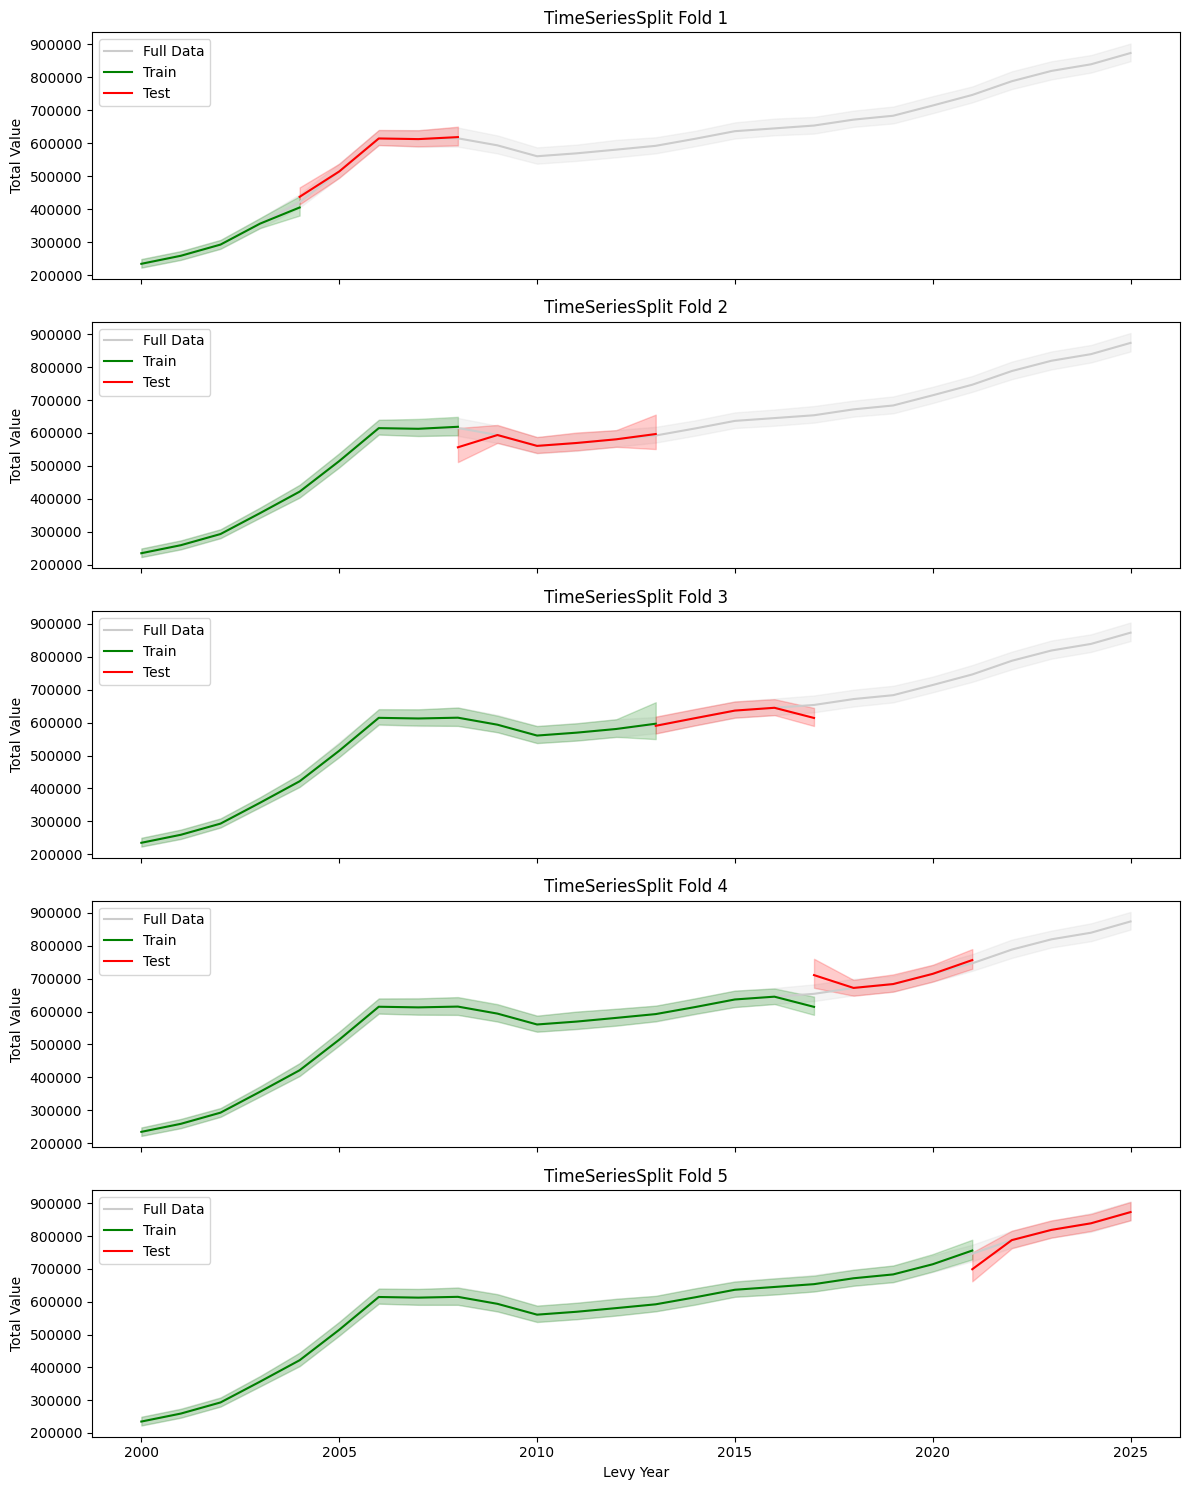

In [23]:
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fig, axes = plt.subplots(n_splits, 1, figsize=(12, 3 * n_splits), sharex=True)

for i, (train_index, test_index) in enumerate(tscv.split(AVAdata)):
    ax = axes[i]

    sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value", 
                 color="0.8", label="Full Data", ax=ax)

    sns.lineplot(data=AVAdata.iloc[train_index], x="Levy Year", y="Total Value",
                 color='green', label='Train', ax=ax)
    
    sns.lineplot(data=AVAdata.iloc[test_index], x="Levy Year", y="Total Value",
                 color='red', label='Test', ax=ax)

    ax.set_title(f"TimeSeriesSplit Fold {i+1}")
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


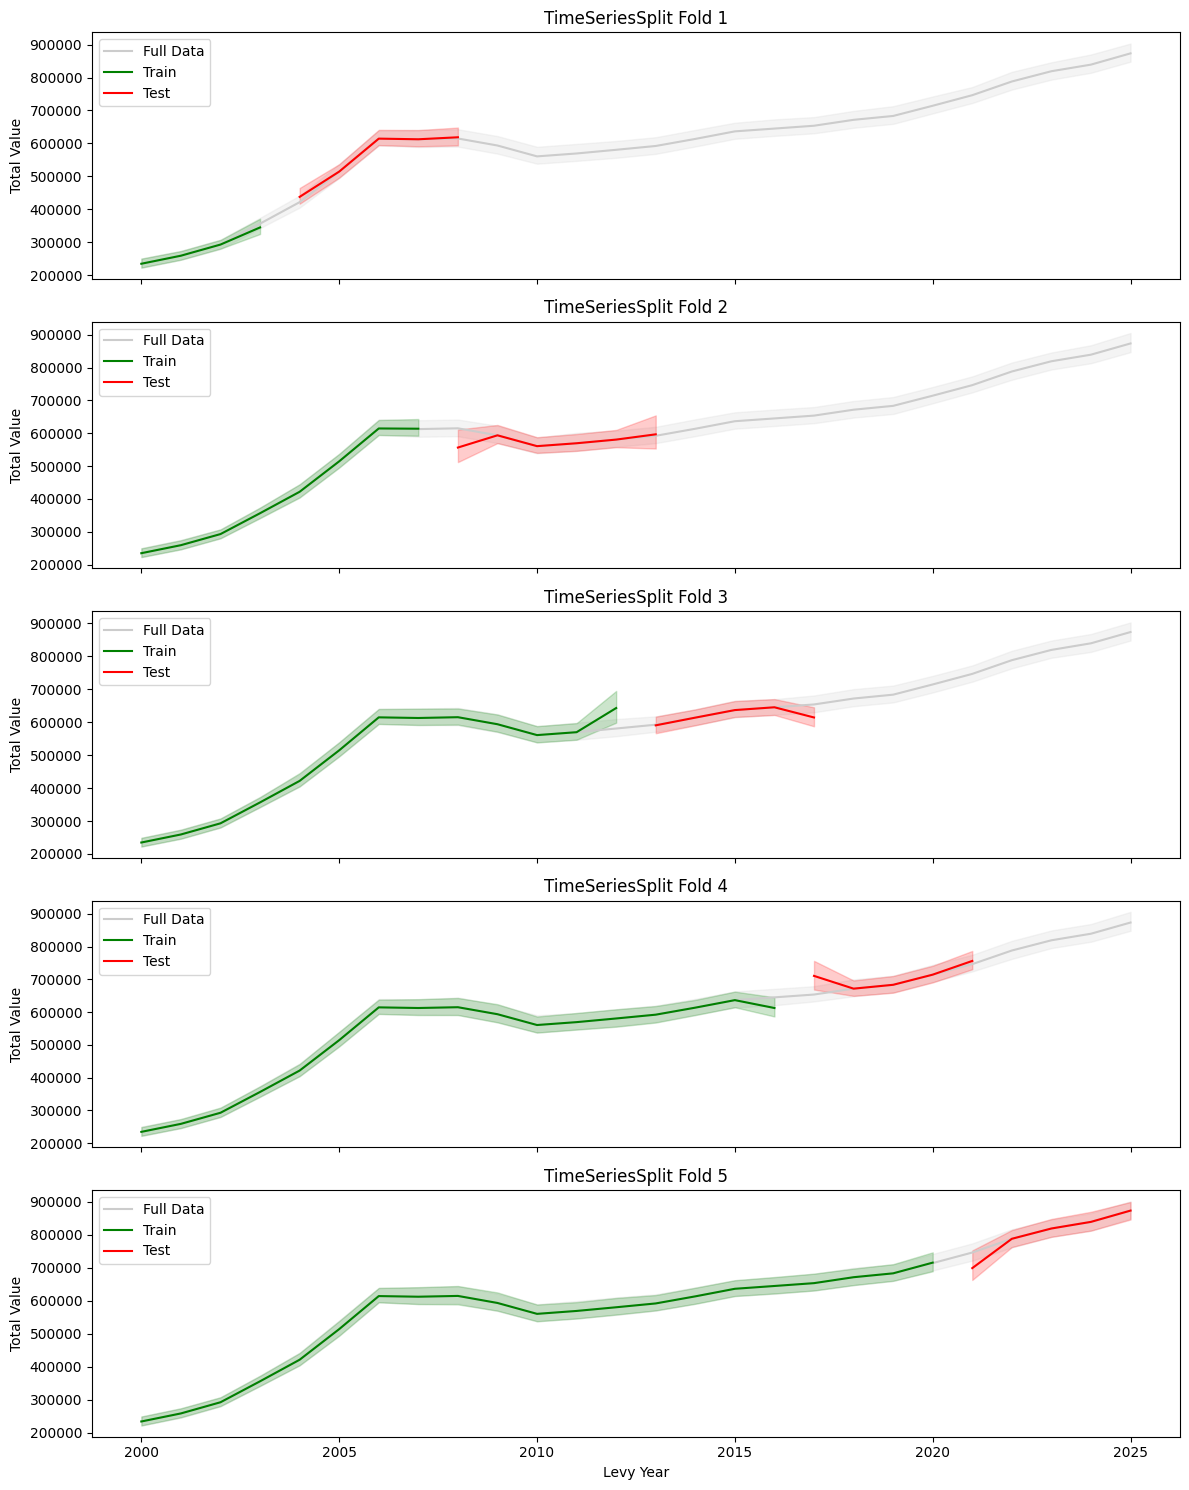

In [24]:
n_splits = 5
gap_size = 30000 # roughly equates to year in gap size
tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap_size)

fig, axes = plt.subplots(n_splits, 1, figsize=(12, 3 * n_splits), sharex=True)

cv_training_years = []
cv_testing_years = []
cv_gap_years = []
for i, (train_idx, test_idx) in enumerate(tscv.split(AVAdata)):

    train_start_end = (train_idx[0], train_idx[-1])
    test_start_end = (test_idx[0], test_idx[-1])
    gap_years = (train_idx[-1], test_idx[0])

    cv_training_years.append(train_start_end)
    cv_testing_years.append(test_start_end)

    ax = axes[i]

    sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value", 
                 color="0.8", label="Full Data", ax=ax)

    sns.lineplot(data=AVAdata.iloc[train_idx], x="Levy Year", y="Total Value",
                 color='green', label='Train', ax=ax)
    
    sns.lineplot(data=AVAdata.iloc[test_idx], x="Levy Year", y="Total Value",
                 color='red', label='Test', ax=ax)

    ax.set_title(f"TimeSeriesSplit Fold {i+1}")
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
    

In [25]:
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

AVAdatacopy = AVAdata.copy()
AVAdatacopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
406165,50637920,2000,31600,117000,148600,22311
289492,13218500,2000,45300,93900,139200,22301
289518,13218000,2000,41100,93400,134500,22314
289544,13217000,2000,41100,85000,126100,22301
289570,13216500,2000,41100,85000,126100,22314


### Feature Creation

In [27]:
AVAdatacopy['Total Value Lag1'] = AVAdatacopy['Total Value'].shift(1)
AVAdatacopy['Land to Building Ratio'] = AVAdatacopy['Land Value'] / AVAdatacopy['Building Value']
AVAdatacopy = AVAdatacopy.dropna()
AVAdatacopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code,Total Value Lag1,Land to Building Ratio
289492,13218500,2000,45300,93900,139200,22301,148600.0,0.482428
289518,13218000,2000,41100,93400,134500,22314,139200.0,0.440043
289544,13217000,2000,41100,85000,126100,22301,134500.0,0.483529
289570,13216500,2000,41100,85000,126100,22314,126100.0,0.483529
289596,13215500,2000,47900,92100,140000,22301,126100.0,0.520087


In [28]:
AVAdatacopy.shape

(792952, 8)

In [29]:
AVAdatacopy['Zip Code'] = AVAdatacopy['Zip Code'].astype('category')
AVAdatacopy.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code,Total Value Lag1,Land to Building Ratio
289492,13218500,2000,45300,93900,139200,22301,148600.0,0.482428
289518,13218000,2000,41100,93400,134500,22314,139200.0,0.440043
289544,13217000,2000,41100,85000,126100,22301,134500.0,0.483529
289570,13216500,2000,41100,85000,126100,22314,126100.0,0.483529
289596,13215500,2000,47900,92100,140000,22301,126100.0,0.520087


C:\Users\barre\AppData\Local\Temp\ipykernel_17716\2171751135.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Zip Code'] = X_train['Zip Code'].astype('category')
C:\Users\barre\AppData\Local\Temp\ipykernel_17716\2171751135.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Zip Code'] = X_test['Zip Code'].astype('category')


Fold 1 MAE: 56180.80
Fold 2 MAE: 60356.39
Fold 3 MAE: 56548.39
Fold 4 MAE: 60660.60
Fold 5 MAE: 55752.58

Test MAE: 62974.77


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

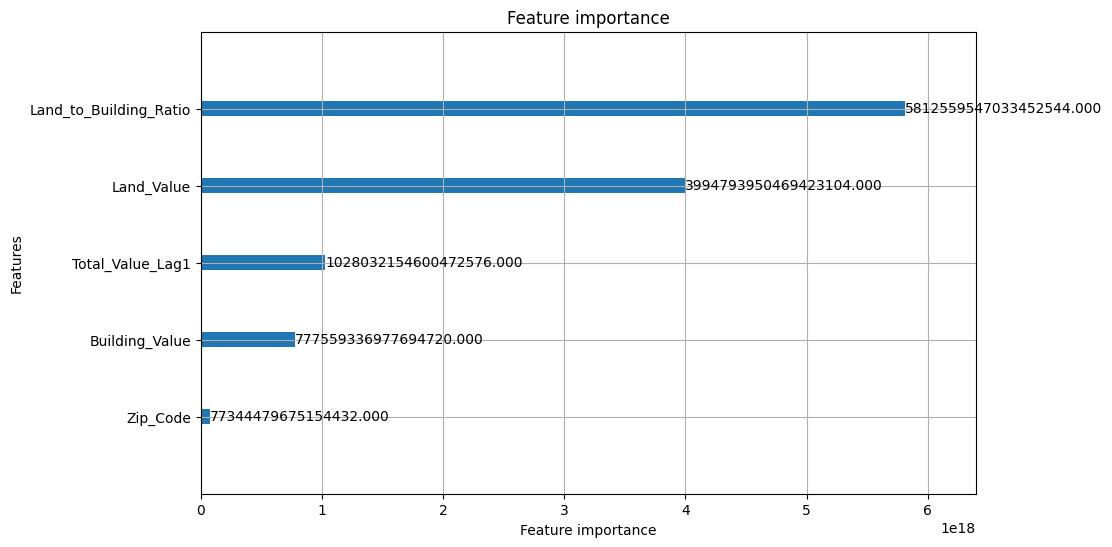

In [121]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

n_splits = 5
gap_size = 1 # roughly equates to year in gap size
tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap_size)

features = ['Land Value', 'Building Value', 'Zip Code', 'Total Value Lag1', 'Land to Building Ratio']
target = 'Total Value'

train_data = AVAdatacopy[AVAdatacopy["Levy Year"] <= 2019]
test_data = AVAdatacopy[AVAdatacopy["Levy Year"] > 2019]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

X_train['Zip Code'] = X_train['Zip Code'].astype('category')
X_test['Zip Code'] = X_test['Zip Code'].astype('category')

model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    verbose=-1,
    random_state=42
)

fold_maes = []
predictions = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        categorical_feature=['Zip Code']
    )

    val_pred = model.predict(X_fold_val)
    mae = mean_absolute_error(y_fold_val, val_pred)
    fold_maes.append(mae)
    print(f"Fold {fold+1} MAE: {mae:.2f}")

    predictions.append(val_pred)

    
final_model = lgb.LGBMRegressor(**model.get_params()).fit(
    X_train, y_train,
    categorical_feature=['Zip Code']
)

test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_pred)
print(f"\nTest MAE: {test_mae:.2f}")

lgb.plot_importance(final_model, importance_type='gain', figsize=(10, 6))

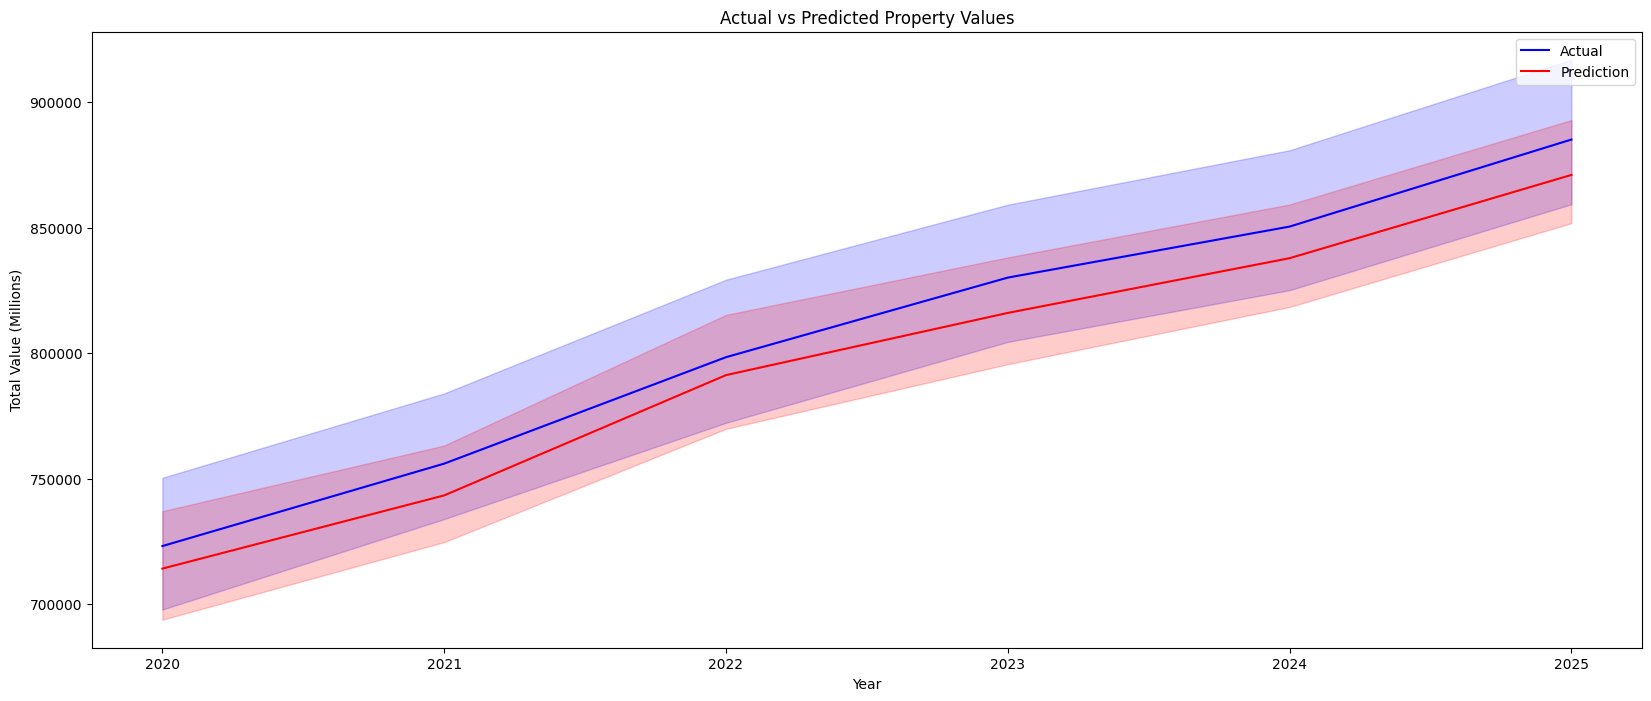

In [123]:
df_test = pd.DataFrame({
    'Year': test_data['Levy Year'],
    'Actual': y_test,
    'Prediction': prediction  # Ensure this variable exists (from model.predict())
})

plt.figure(figsize=(20, 8))
sns.lineplot(data=df_test, x='Year', y='Actual', label='Actual', color='blue')
sns.lineplot(data=df_test, x='Year', y='Prediction', label='Prediction', color='red')

plt.title('Actual vs Predicted Property Values')
plt.ylabel('Total Value (Millions)')
plt.legend()
plt.show()

### Time Series Analysis For Each Unique Zip Code

In [126]:
unique_zipcodes = [22206, 22301, 22302, 22304, 22305, 22311, 22312, 22314]

In [128]:
AVA22206data = AVAdatacopy[AVAdatacopy['Zip Code'] == unique_zipcodes[0]]
AVA22206data

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code,Total Value Lag1,Land to Building Ratio
262749,50220340,2000,19900,40500,60400,22206,0.0,0.491358
262801,50220390,2000,19900,41400,61300,22206,144900.0,0.480676
394769,50634630,2000,40000,106100,146100,22206,166800.0,0.377003
392372,50344760,2000,22700,104900,127600,22206,142400.0,0.216397
382571,17548130,2000,18500,73600,92100,22206,109000.0,0.251359
...,...,...,...,...,...,...,...,...
4550,50227290,2025,156858,482463,639321,22206,824311.0,0.325119
4524,50227280,2025,154429,476561,630990,22206,503240.0,0.324049
382546,17548130,2025,158666,295411,454077,22206,281030.0,0.537103
4472,50227260,2025,154429,476561,630990,22206,1348935.0,0.324049


In [130]:
features = ['Land Value', 'Building Value', 'Total Value Lag1', 'Land to Building Ratio']
target = 'Total Value'

AVA22206data = AVAdatacopy[AVAdatacopy['Zip Code'] == unique_zipcodes[0]]

train_data = AVA22206data[AVA22206data["Levy Year"] <= 2019]
test_data = AVA22206data[AVA22206data["Levy Year"] > 2019]

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    verbose=-1,
    random_state=42
)

fold_maes = []
predictions = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)]
    )

    val_pred = model.predict(X_fold_val)
    mae = mean_absolute_error(y_fold_val, val_pred)
    fold_maes.append(mae)
    print(f"Fold {fold+1} MAE: {mae:.2f}")

    predictions.append(val_pred)

    
final_model = lgb.LGBMRegressor(**model.get_params()).fit(
    X_train, y_train
)

test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_pred)
print(f"\nTest MAE: {test_mae:.2f}")

Fold 1 MAE: 25387.54
Fold 2 MAE: 10775.80
Fold 3 MAE: 4739.97
Fold 4 MAE: 3930.55
Fold 5 MAE: 3937.39

Test MAE: 19802.09


In [139]:
len(prediction)

191372

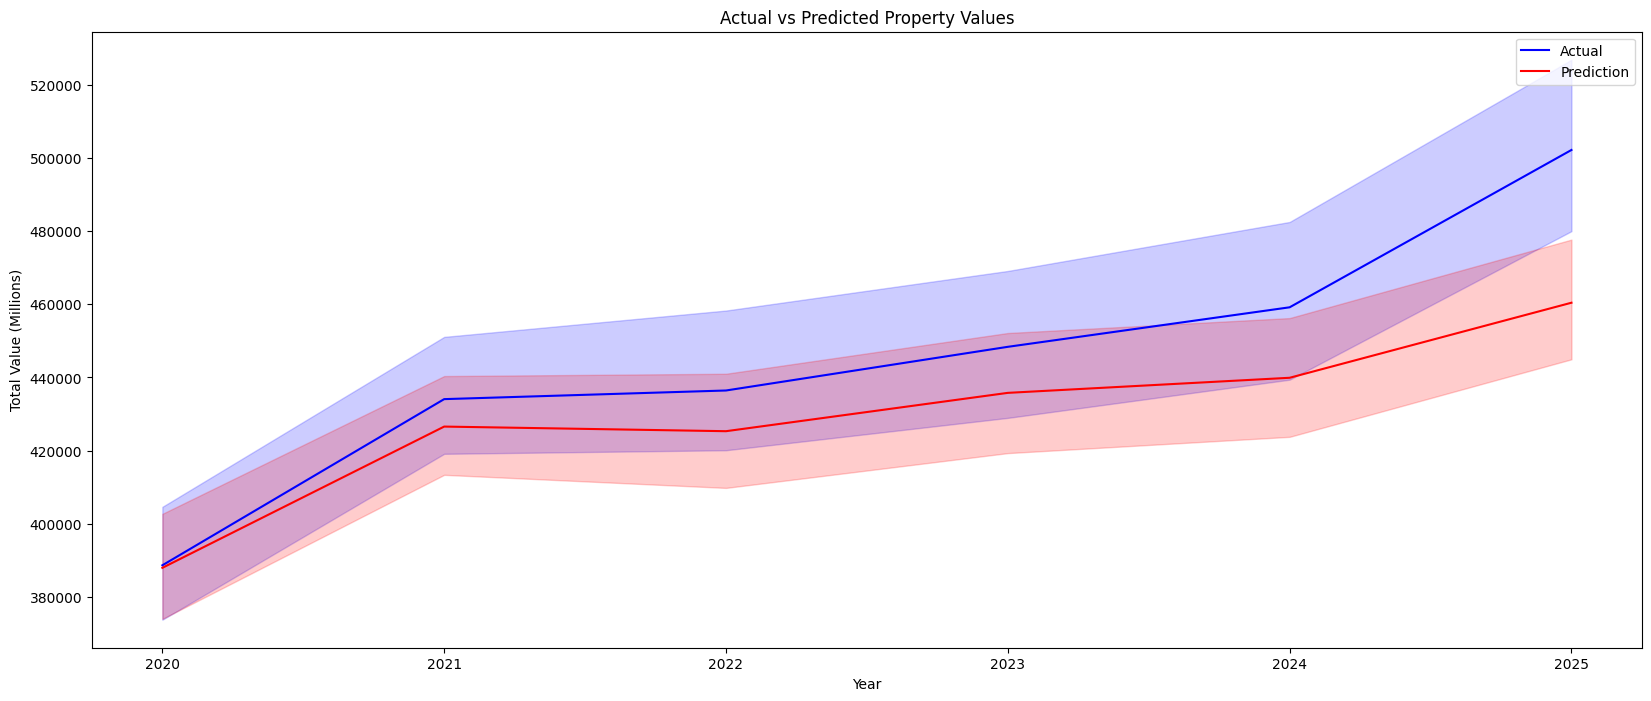

In [141]:
df_test = pd.DataFrame({
    'Year': test_data['Levy Year'],
    'Actual': y_test,
    'Prediction': test_pred  # Ensure this variable exists (from model.predict())
})

plt.figure(figsize=(20, 8))
sns.lineplot(data=df_test, x='Year', y='Actual', label='Actual', color='blue')
sns.lineplot(data=df_test, x='Year', y='Prediction', label='Prediction', color='red')

plt.title('Actual vs Predicted Property Values for Zip Code: 22206')
plt.ylabel('Total Value (Millions)')
plt.legend()
plt.show()